In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##### Here, we have used the UCI ML Dataset https://archive.ics.uci.edu/dataset/235/individual+household+electric+power+consumption

This UCI dataset (ID 235) spans Dec 2006–Nov 2010, with ~1.25% missing values shown as empty fields between semicolons; preprocess by forward-filling or interpolation for robust analysis. Key columns include timestamp (Date/Time), Global_active_power (kW), Voltage (V), Global_intensity (A), and sub-meterings (Wh) for kitchen/laundry/water heater—ideal for simulating rural sub-systems.

In [2]:
#Loading the dataset
power = pd.read_csv(r"D:\AI_For_Bharat\household_power_consumption.txt",sep=';')

C:\Users\Pranav Kavishwar\AppData\Local\Temp\ipykernel_15244\3978991287.py:2: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  power = pd.read_csv(r"D:\AI_For_Bharat\household_power_consumption.txt",sep=';')


In [3]:
power.shape

(2075259, 9)

In [4]:
power.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [5]:
power.describe()

,Sub_metering_3
count,2.049280e+06
mean,6.458447e+00
std,8.437154e+00
min,0.000000e+00
25%,0.000000e+00
50%,1.000000e+00
75%,1.700000e+01
max,3.100000e+01


In [6]:
power.isnull().sum()

Date                         0
Time                         0
Global_active_power          0
Global_reactive_power        0
Voltage                      0
Global_intensity             0
Sub_metering_1               0
Sub_metering_2               0
Sub_metering_3           25979
dtype: int64

From the above output we can see that only the "Sub_metering_3" variable has null values. 

In [7]:
#Calculating the percentage of Null values for Sub_metering_3 column

(int(power['Sub_metering_3'].isnull().sum())/power.shape[0])*100

1.2518437457686005

Here, we can see that ~1.25% of total values are Null entries.

<Axes: title={'center': 'Sub_metering_3'}, ylabel='Sub_metering_3'>

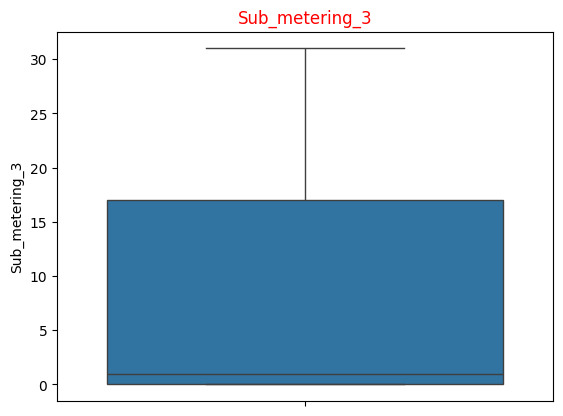

In [8]:
#Boxplot of Sub_metering_3 column
plt.title('Sub_metering_3', fontdict={'color' : 'Red'})

sns.boxplot(power['Sub_metering_3'])

In [9]:
power['Sub_metering_3'].describe()

count    2.049280e+06
mean     6.458447e+00
std      8.437154e+00
min      0.000000e+00
25%      0.000000e+00
50%      1.000000e+00
75%      1.700000e+01
max      3.100000e+01
Name: Sub_metering_3, dtype: float64

As per the statistics, this column Sub_Metering_3 is highly skewed. Mean value is 6.45 which is distorted to high values whereas Median i.e. 50th percentile is more robust to outliers. So let's replace the missing values with the Median value.

In [10]:
power['Sub_metering_3'].fillna(power['Sub_metering_3'].median(), inplace=True)

In [11]:
power.isnull().sum()

Date                     0
Time                     0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

Now, we can see that there no Null values in the dataset..

In [12]:
power.columns

Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')

Let's create a list of numeric columns which will help us to capture anomalies. 

In [14]:
numeric_cols = ['Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3']

for n in numeric_cols:
       print(power[n].dtype)

object
object
object
object
object
object
float64


Here, we can see that except the Sub_metering_3 variable, rest all are of generic object datatype in Pandas. Firstly, let's remove the 'dirty' numeric strings. These consists of things like empty strings, trailing spaces, or non-standard characters (like commas or currency symbols).

In [15]:
for n in numeric_cols:
    power[n] = (power[n].astype(str).str.strip().replace(['', 'None', 'nan', '-'], pd.NA))

In [16]:
#Converting the variables values to numeric values

for n in numeric_cols:
    power[n] = pd.to_numeric(power[n], errors='coerce')

In [17]:
for n in numeric_cols:
    print(power[n].dtype)

float64
float64
float64
float64
float64
float64
float64


Now, we can see that all variables to be used for anomaly detection are of type float. 

In [18]:
power.shape

(2075259, 9)

In [19]:
power.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


<Axes: title={'center': 'Voltage'}, ylabel='Voltage'>

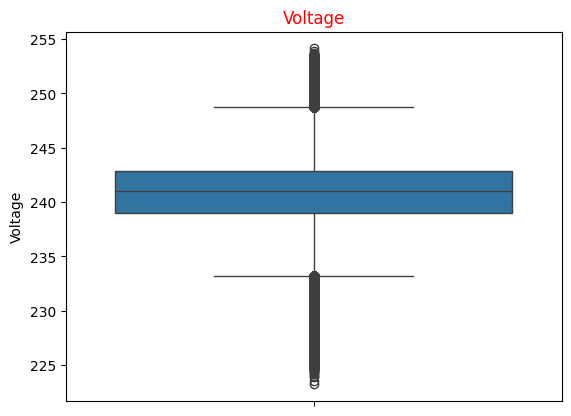

In [20]:
#Volatge variable distribution

plt.title('Voltage', fontdict={'color' : 'Red'})

sns.boxplot(power['Voltage'])

As seen from the above boxplot image of Voltage, the average range of volage value is approximately between 238V-242V.

## Isolation Forest Machine Learning Algorithm 

In [21]:
#Importing isolation forest algorithm from sklearn library

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

In [22]:
scaler = StandardScaler()
X = scaler.fit_transform(power[numeric_cols])

In [23]:
iso = IsolationForest(contamination=0.01, random_state=42)
power['anamoly'] = iso.fit_predict(X)

In [24]:
print(f"Anomalies: {(power['anamoly']==-1).sum()} / {len(power)}")

Anomalies: 20753 / 2075259


Now, let's plot the anomalies captured for voltage. 

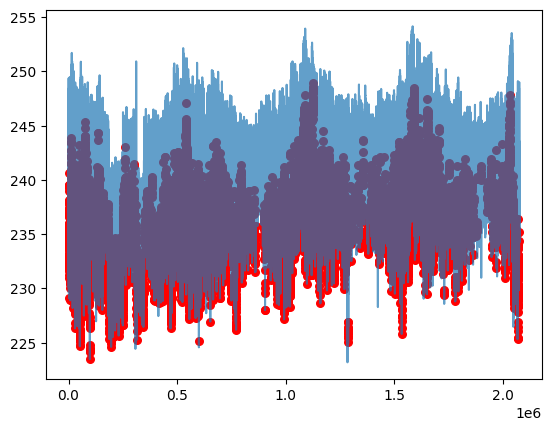

In [25]:
plt.plot(power.index, power['Voltage'], alpha=0.7)

plt.scatter(power[power['anamoly']==-1].index, power[power['anamoly']==-1]['Voltage'], c='red', s=30)

plt.show()

From the above image, we can see the red points indicate the voltage drops.  

C:\Users\Pranav Kavishwar\AppData\Local\Temp\ipykernel_15244\3069000537.py:15: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\Pranav Kavishwar\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


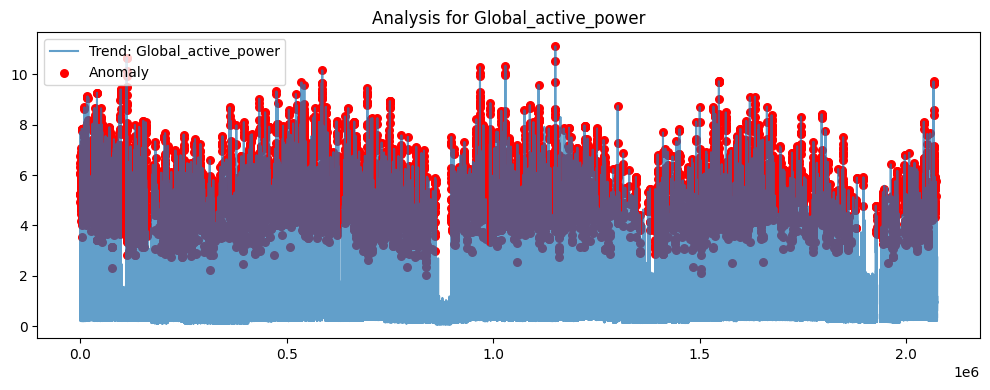

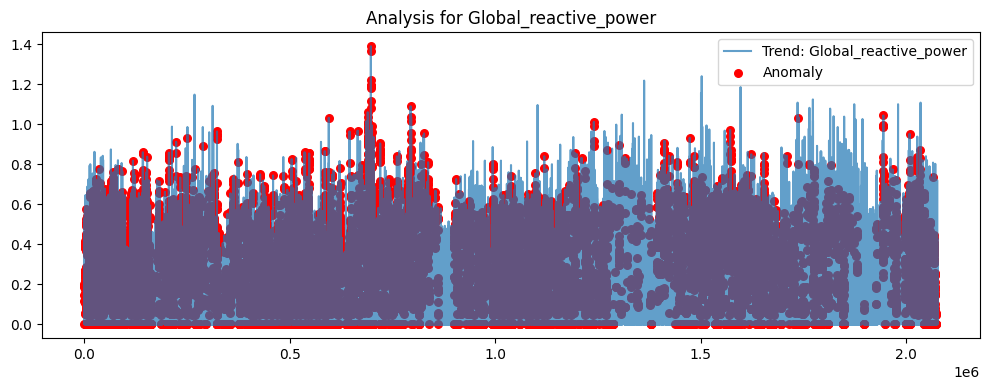

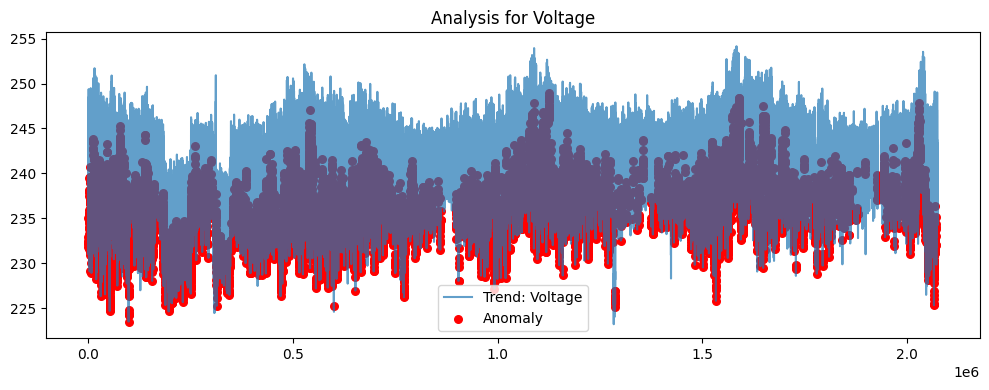

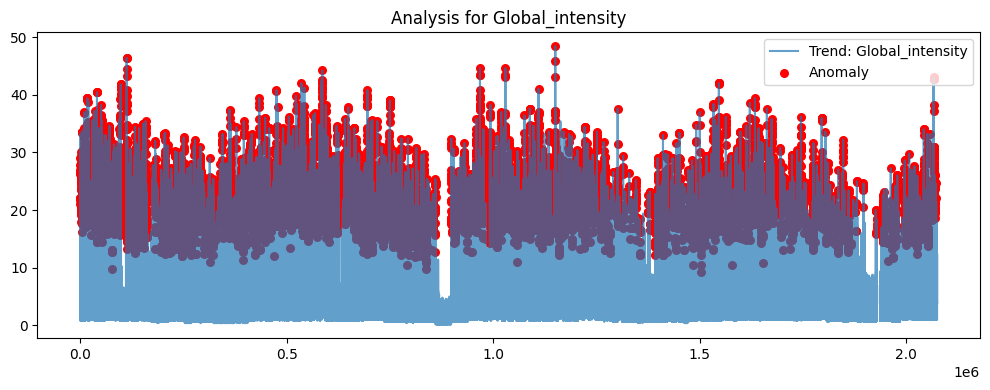

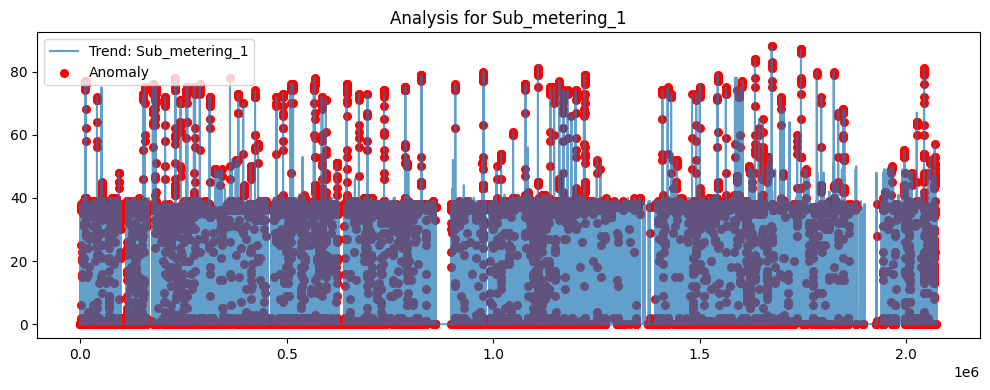

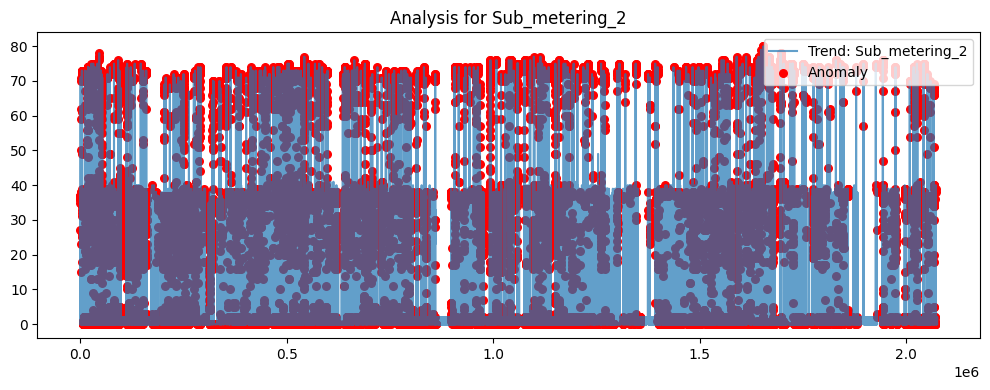

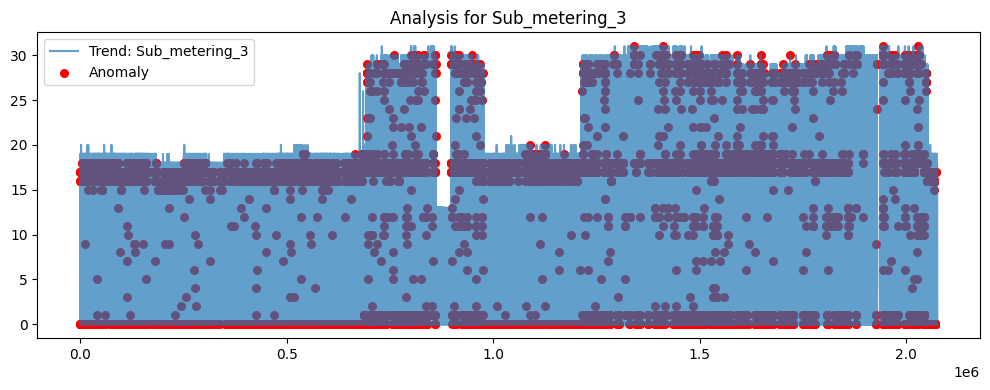

In [26]:
#Plotting the anomalies for other variables as well

for n in numeric_cols:
    plt.figure(figsize=(10, 4)) # Forces a brand new window/plot area
    
    # Line plot of the data
    plt.plot(power.index, power[n], alpha=0.7, label=f'Trend: {n}')
    
    # Scatter plot of anomalies
    anomalies = power[power['anamoly'] == -1]
    plt.scatter(anomalies.index, anomalies[n], c='red', s=30, label='Anomaly')
    
    plt.title(f'Analysis for {n}')
    plt.legend()
    plt.tight_layout()
    plt.show() # In a loop, this clears the canvas for the next iteration

### Anomalies scenarios : 

1.	Voltage spike without Active power spike  Grid issue
2.	Active power spike without voltage change  Appliance fault
3.	Sub-metering-1 spike + Global intensity spike  Kitchen problem
4.	Reactive power surge  Power factor issue
5.	All 7 aligned spikes  Serious Grid events

As mentioned in the above scenarios, the ML model with Isolation forest algorithms monitor these anomalies and expected issues relating to the spikes observed. 

In [27]:
power.shape

(2075259, 10)

In [28]:
power.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,anamoly
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,1
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,1
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,1
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,1
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,1


In [29]:
#Exporting the Dataset in CSV format with the anomalies column

power.to_csv('output.csv',index=False)

Output CSV file has been generated. Now, this file will act as an input to our LLM Application. 